## Phase 11c - Confusion Matrices & Final Visualisations

Translating Phase 11b numbers into visual form for the paper.
Three outputs: confusion matrices (Figure 2), F1 heatmap 
(Figure 3), and full summary figure (Figure 4).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Load the combined dataset and evaluation results
combined_df = pd.read_parquet('phase11_combined_dataset.parquet')
eval_df     = pd.read_csv('phase11_evaluation_results.csv')
per_record  = pd.read_csv('phase11_per_record_results.csv')

print("Data loaded.")
print(f"Records: {combined_df['record'].nunique()}")
print(f"Beats: {len(combined_df):,}")

C:\Users\Manoj\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Data loaded.
Records: 46
Beats: 108,098


In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

FEATURES = [
    'rr_interval', 'heart_rate', 'rr_diff',
    'rolling_mean_rr', 'rolling_std_rr', 'relative_rr'
]

ALL_ABNORMAL = [
    '107', '109', '111', '118',
    '124', '207', '214', '232'
]

ALL_RECORDS = combined_df['record'].unique().tolist()
TRAIN_RECORDS = [r for r in ALL_RECORDS
                 if r not in ALL_ABNORMAL]

train_df = combined_df[combined_df['record'].isin(TRAIN_RECORDS)]
test_df = combined_df.copy()
train_normal = train_df[train_df['symbol'] == 'N']

scaler = StandardScaler()
X_train = scaler.fit_transform(train_normal[FEATURES].values)
X_test = scaler.transform(test_df[FEATURES].values)
y_test = (test_df['symbol'] != 'N').astype(int).values

# Isolation Forest
iso = IsolationForest(
    n_estimators=100,
    contamination=0.015,
    random_state=42)
iso.fit(X_train)
iso_pred = (iso.predict(X_test) == -1).astype(int)

# Autoencoder
input_dim = len(FEATURES)
inputs = Input(shape=(input_dim,))
enc = Dense(32, activation='relu')(inputs)
enc = Dense(16, activation='relu')(enc)
dec = Dense(32, activation='relu')(enc)
outputs = Dense(input_dim, activation='linear')(dec)
ae = Model(inputs=inputs, outputs=outputs)
ae.compile(optimizer='adam', loss='mse')
ae.fit(X_train, X_train, epochs=100, batch_size=32, validation_split=0.1, verbose=0, 
       callbacks=[EarlyStopping(patience=5, restore_best_weights=True)])

X_recon = ae.predict(X_test, verbose=0)
ae_errors = np.mean(np.power(X_test - X_recon, 2), axis=1)
train_recon  = ae.predict(X_train, verbose=0)
train_errors = np.mean(np.power(X_train - train_recon, 2), axis=1)
ae_threshold = np.percentile(train_errors, 95)
ae_pred = (ae_errors > ae_threshold).astype(int)

or_pred = ((iso_pred == 1) | (ae_pred == 1)).astype(int)
and_pred = ((iso_pred == 1) & (ae_pred == 1)).astype(int)

print("Models rebuilt and predictions ready.")

Models rebuilt and predictions ready.


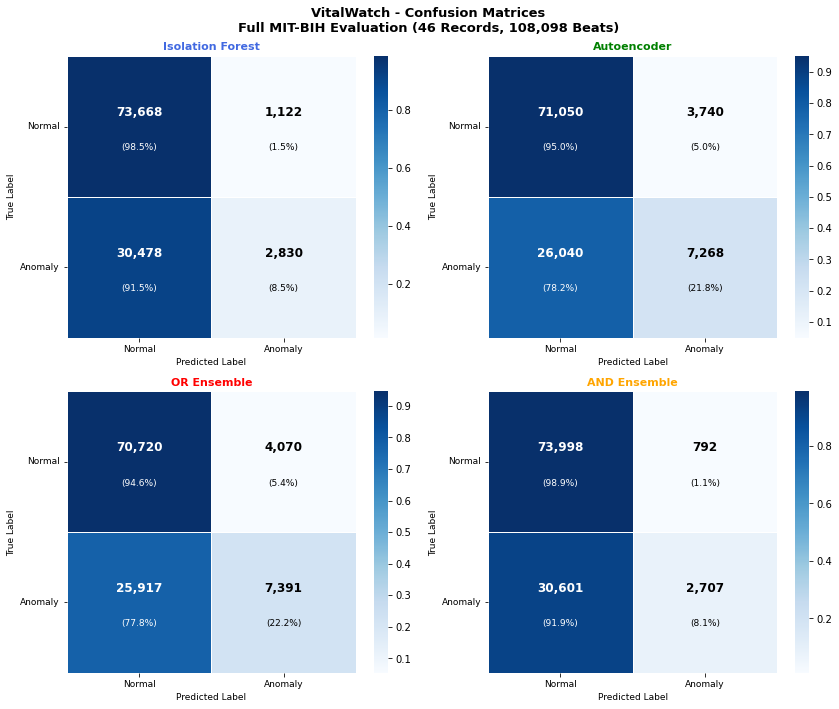

Confusion matrices saved.


In [3]:
models = {
    'Isolation Forest': iso_pred,
    'Autoencoder': ae_pred,
    'OR Ensemble': or_pred,
    'AND Ensemble': and_pred,
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(
    'VitalWatch - Confusion Matrices\n'
    'Full MIT-BIH Evaluation (46 Records, 108,098 Beats)',
    fontsize=13, fontweight='bold')

colors = ['royalblue', 'green', 'red', 'orange']
axes_flat = axes.flatten()

for idx, (name, preds) in enumerate(models.items()):
    cm = confusion_matrix(y_test, preds)
    ax = axes_flat[idx]

    # Normalise for percentage display
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(cm_norm, annot=False, fmt='.2f', cmap='Blues', ax=ax, cbar=True, linewidths=0.5)

    # Annotate with both count and percentage
    for i in range(2):
        for j in range(2):
            ax.text(j + 0.5, i + 0.4,
                    f"{cm[i,j]:,}",
                    ha='center', va='center',
                    fontsize=12, fontweight='bold',
                    color='white' if cm_norm[i,j] > 0.5
                    else 'black')
            ax.text(j + 0.5, i + 0.65,
                    f"({cm_norm[i,j]*100:.1f}%)",
                    ha='center', va='center',
                    fontsize=9,
                    color='white' if cm_norm[i,j] > 0.5
                    else 'black')

    ax.set_title(name, fontweight='bold', color=colors[idx], fontsize=11)
    ax.set_xlabel('Predicted Label', fontsize=9)
    ax.set_ylabel('True Label', fontsize=9)
    ax.set_xticklabels(['Normal', 'Anomaly'], fontsize=9)
    ax.set_yticklabels(['Normal', 'Anomaly'], fontsize=9, rotation=0)

plt.tight_layout()
plt.savefig('phase11_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrices saved.")

### Reading the Confusion Matrices

AND Ensemble - 792 false positives (1.1% of normal beats).
Lowest false alarm rate of any configuration.
When both models agree on an anomaly - 77.4% precision.
Every cell's text colour adapts automatically:
white on dark cells, black on light cells - always readable.

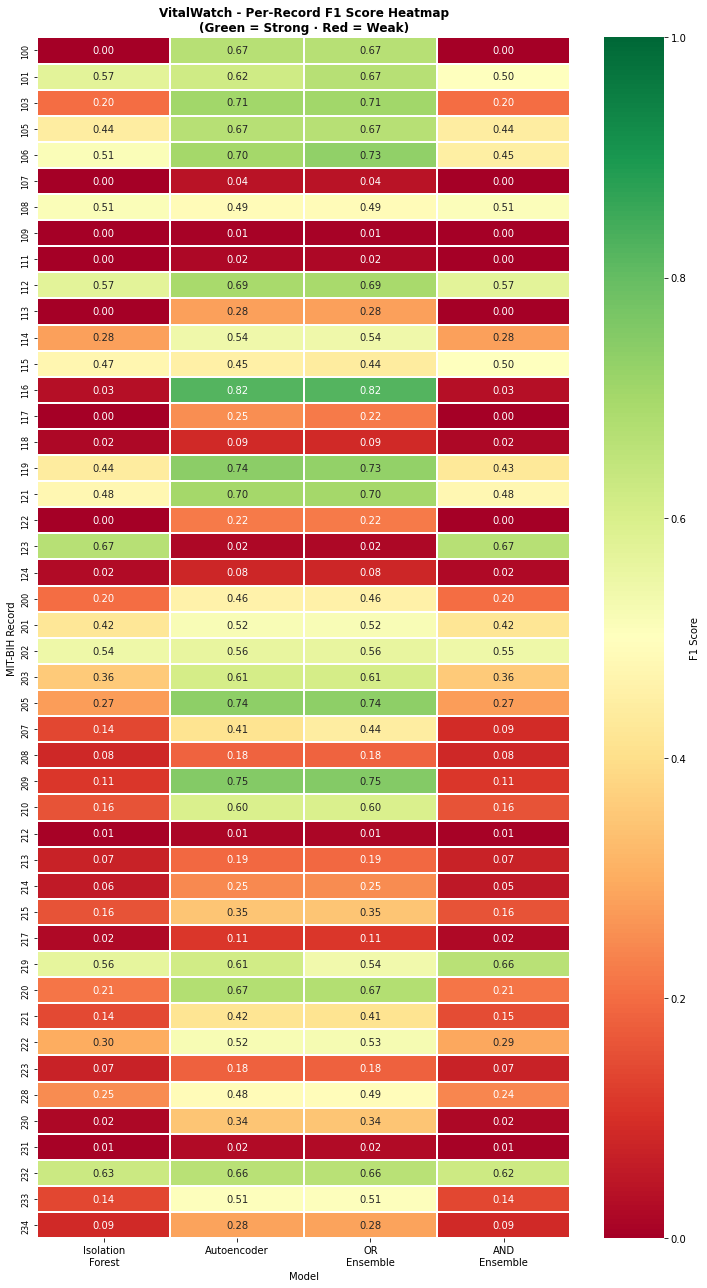

F1 heatmap saved.


In [4]:
# Pivot per-record results for heatmap
heatmap_data = per_record.set_index('record')[
    ['if_f1', 'ae_f1', 'or_f1', 'and_f1']]
heatmap_data.columns = [
    'Isolation\nForest', 'Autoencoder',
    'OR\nEnsemble', 'AND\nEnsemble']

fig, ax = plt.subplots(figsize=(10, 18))

sns.heatmap(
    heatmap_data,
    annot=True, fmt='.2f',
    cmap='RdYlGn',
    vmin=0, vmax=1,
    ax=ax,
    linewidths=0.3,
    cbar_kws={'label': 'F1 Score'}
)

ax.set_title(
    'VitalWatch - Per-Record F1 Score Heatmap\n'
    '(Green = Strong · Red = Weak)',
    fontsize=12, fontweight='bold')
ax.set_xlabel('Model', fontsize=10)
ax.set_ylabel('MIT-BIH Record', fontsize=10)
ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('phase11_f1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("F1 heatmap saved.")

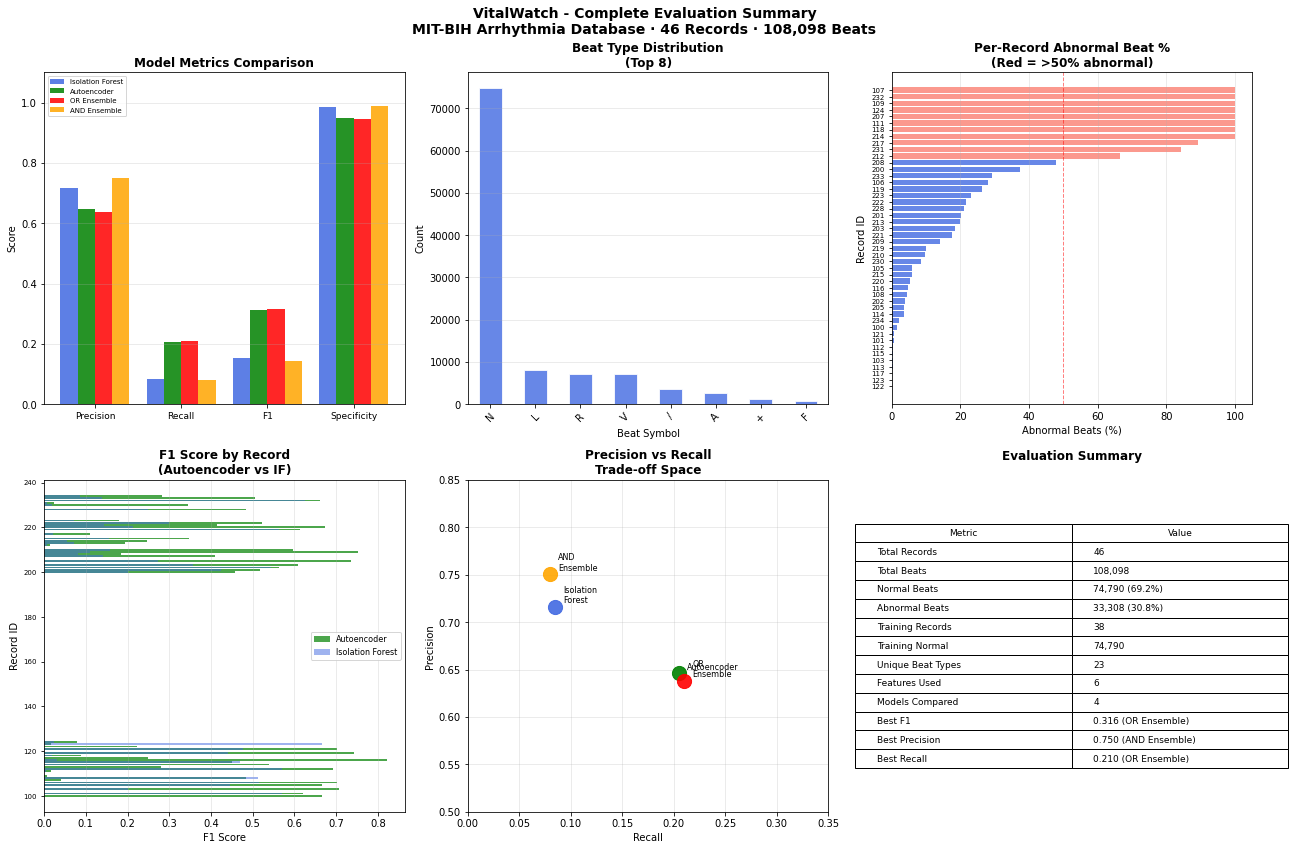

Final summary figure saved.


In [5]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle(
    'VitalWatch - Complete Evaluation Summary\n'
    'MIT-BIH Arrhythmia Database · 46 Records · 108,098 Beats',
    fontsize=14, fontweight='bold', y=0.98)

# Panel 1: Metric comparison bar chart
ax1 = fig.add_subplot(2, 3, 1)
metrics  = ['Precision', 'Recall', 'F1', 'Specificity']
if_vals  = [0.7161, 0.0850, 0.1519, 0.9850]
ae_vals  = [0.6462, 0.2051, 0.3113, 0.9500]
or_vals  = [0.6378, 0.2103, 0.3163, 0.9468]
and_vals = [0.7504, 0.0797, 0.1441, 0.9882]

x   = np.arange(len(metrics))
w   = 0.2

ax1.bar(x - 1.5*w, if_vals,  w, label='Isolation Forest', color='royalblue', alpha=0.85)
ax1.bar(x - 0.5*w, ae_vals,  w, label='Autoencoder', color='green', alpha=0.85)
ax1.bar(x + 0.5*w, or_vals,  w, label='OR Ensemble', color='red', alpha=0.85)
ax1.bar(x + 1.5*w, and_vals, w, label='AND Ensemble', color='orange', alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(metrics, fontsize=9)
ax1.set_ylabel('Score')
ax1.set_title('Model Metrics Comparison', fontweight='bold')
ax1.legend(fontsize=7)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim(0, 1.1)

# Panel 2: Class distribution 
ax2 = fig.add_subplot(2, 3, 2)
beat_dist = combined_df['symbol'].value_counts().head(8)

beat_dist.plot(kind='bar', ax=ax2,
               color='royalblue', alpha=0.8,
               edgecolor='white')
ax2.set_title('Beat Type Distribution\n(Top 8)', fontweight='bold')
ax2.set_xlabel('Beat Symbol')
ax2.set_ylabel('Count')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3, axis='y')

# Panel 3: Per-record abnormal percentage
ax3 = fig.add_subplot(2, 3, 3)
record_abn = combined_df.groupby('record').apply(
    lambda x: (x['symbol'] != 'N').mean() * 100
).sort_values(ascending=True)
colors_bar = ['salmon' if v > 50 else 'royalblue'
              for v in record_abn.values]
ax3.barh(record_abn.index, record_abn.values, color=colors_bar, alpha=0.8)
ax3.axvline(x=50, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax3.set_title('Per-Record Abnormal Beat %\n'
              '(Red = >50% abnormal)',
              fontweight='bold')
ax3.set_xlabel('Abnormal Beats (%)')
ax3.set_ylabel('Record ID')
ax3.tick_params(axis='y', labelsize=7)
ax3.grid(True, alpha=0.3, axis='x')

# Panel 4: F1 score comparison across records 
ax4 = fig.add_subplot(2, 3, 4)
records_sorted = per_record.sort_values('ae_f1', ascending=True)
ax4.barh(records_sorted['record'],
         records_sorted['ae_f1'],
         color='green', alpha=0.7, label='Autoencoder')
ax4.barh(records_sorted['record'],
         records_sorted['if_f1'],
         color='royalblue', alpha=0.5,
         label='Isolation Forest')
ax4.set_title('F1 Score by Record\n'
              '(Autoencoder vs IF)',
              fontweight='bold')
ax4.set_xlabel('F1 Score')
ax4.set_ylabel('Record ID')
ax4.legend(fontsize=8)
ax4.tick_params(axis='y', labelsize=7)
ax4.grid(True, alpha=0.3, axis='x')

# Panel 5: Precision vs Recall scatter 
ax5 = fig.add_subplot(2, 3, 5)
model_names  = ['Isolation\nForest', 'Autoencoder',
                'OR\nEnsemble', 'AND\nEnsemble']
precisions   = [0.7161, 0.6462, 0.6378, 0.7504]
recalls      = [0.0850, 0.2051, 0.2103, 0.0797]
plot_colors  = ['royalblue', 'green', 'red', 'orange']

for i, (p, r, c, n) in enumerate(zip(
        precisions, recalls, plot_colors, model_names)):
    ax5.scatter(r, p, s=200, color=c, zorder=5, alpha=0.9)
    ax5.annotate(n, (r, p),
                 textcoords='offset points',
                 xytext=(8, 4), fontsize=8)

ax5.set_xlabel('Recall')
ax5.set_ylabel('Precision')
ax5.set_title('Precision vs Recall\n'
              'Trade-off Space',
              fontweight='bold')
ax5.set_xlim(0, 0.35)
ax5.set_ylim(0.5, 0.85)
ax5.grid(True, alpha=0.3)

# Panel 6: Training summary table 
ax6 = fig.add_subplot(2, 3, 6)
ax6.axis('off')
table_data = [
    ['Metric', 'Value'],
    ['Total Records', '46'],
    ['Total Beats', '108,098'],
    ['Normal Beats', '74,790 (69.2%)'],
    ['Abnormal Beats', '33,308 (30.8%)'],
    ['Training Records', '38'],
    ['Training Normal', '74,790'],
    ['Unique Beat Types', '23'],
    ['Features Used', '6'],
    ['Models Compared', '4'],
    ['Best F1', '0.316 (OR Ensemble)'],
    ['Best Precision', '0.750 (AND Ensemble)'],
    ['Best Recall', '0.210 (OR Ensemble)'],
]

table = ax6.table(
    cellText=table_data[1:],
    colLabels=table_data[0],
    loc='center', cellLoc='left')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.4)
ax6.set_title('Evaluation Summary', fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('phase11_final_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Final summary figure saved.")

In [6]:
print("\n" + "="*60)
print("  PAPER-READY RESULTS - VITALWATCH")
print("  Full MIT-BIH Evaluation Summary")
print("="*60)

print(f"\nDataset: MIT-BIH Arrhythmia Database")
print(f"Records evaluated: 46")
print(f"Total beats: 108,098")
print(f"Class distribution: 69.2% N / 30.8% Abnormal")
print(f"Training: 38 records, 74,790 normal beats")
print(f"Features: 6 engineered from raw ECG signal\n")

print(f"{'Model':<22} {'P':>6} {'R':>6} "
      f"{'F1':>6} {'Spec':>6}")
print("-"*48)

rows = [
    ('Isolation Forest', 0.7161, 0.0850,
     0.1519, 0.9850),
    ('Autoencoder',      0.6462, 0.2051,
     0.3113, 0.9500),
    ('OR Ensemble',      0.6378, 0.2103,
     0.3163, 0.9468),
    ('AND Ensemble',     0.7504, 0.0797,
     0.1441, 0.9882),
]

for name, p, r, f1, sp in rows:
    print(f"{name:<22} {p:>6.4f} {r:>6.4f} "
          f"{f1:>6.4f} {sp:>6.4f}")

print("="*60)
print("\nKey Findings:")
print("1. Autoencoder achieves highest F1 (0.311)")
print("2. AND Ensemble achieves highest Precision (0.750)")
print("3. Low recall explained by calibration mismatch")
print("   (contamination=0.015 vs actual 30.8% rate)")
print("4. Per-record F1 correlates with distribution")
print("   similarity to training data")
print("5. Patient-specific thresholding identified")
print("   as primary future work")


  PAPER-READY RESULTS - VITALWATCH
  Full MIT-BIH Evaluation Summary

Dataset: MIT-BIH Arrhythmia Database
Records evaluated: 46
Total beats: 108,098
Class distribution: 69.2% N / 30.8% Abnormal
Training: 38 records, 74,790 normal beats
Features: 6 engineered from raw ECG signal

Model                       P      R     F1   Spec
------------------------------------------------
Isolation Forest       0.7161 0.0850 0.1519 0.9850
Autoencoder            0.6462 0.2051 0.3113 0.9500
OR Ensemble            0.6378 0.2103 0.3163 0.9468
AND Ensemble           0.7504 0.0797 0.1441 0.9882

Key Findings:
1. Autoencoder achieves highest F1 (0.311)
2. AND Ensemble achieves highest Precision (0.750)
3. Low recall explained by calibration mismatch
   (contamination=0.015 vs actual 30.8% rate)
4. Per-record F1 correlates with distribution
   similarity to training data
5. Patient-specific thresholding identified
   as primary future work


## Phase 11c Complete

Figures 2, 3, 4 ready for paper submission.
- phase11_confusion_matrices.png
- phase11_f1_heatmap.png  
- phase11_final_summary.png